# Leverage Rotation (TQQQ + 200SMA) — the quant teardown 🎢

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![2000 cohort survives?: Busted](https://img.shields.io/badge/2000_cohort_survives%3F-Busted-8b949e?style=flat-square)

**Claim.** Hold TQQQ (3x daily Nasdaq-100) while QQQ closes above its 200-day SMA; T-bills below (Gayed 2016, *Leverage for the Long Run*; r/LETFs folklore). Promise: *3x upside without 3x crashes.*

**Design.** Signal on QQQ's close vs its own 200SMA; position effective the NEXT day (one execution lag, applied once). Instrument: real TQQQ where it exists (2010-02→), a synthesised 3x before that: `r₃ₓ = 3·r_QQQ − 2·rf − 2.5%/252` with rf = ^IRX, all-in fee calibrated once vs the real fund. Costs one-way × full NAV per switch (headline 5 bps). Cash leg accrues ^IRX; **Sharpe races are excess-vs-excess**. As-of **2026-06-30**, fingerprint `82b00d3939c8`; canonical numbers frozen in `R` (mirror of [docs/results.md](../docs/results.md)).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from leverage_rotation_200sma import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    QQQ = data.qqq_returns(PX)
    RF = data.rf_daily(PX)
    SIM3 = data.sim3x_returns(QQQ, RF)
    TQQQ = data.tqqq_returns(PX)
    SIG = st.sma_signal(PX["QQQ"].dropna())
    CASH = RF.reindex(QQQ.index).ffill()
    ROT, NSW = st.rotation_returns(SIM3, CASH, SIG, cost_bps=5.0)
else:
    PX = QQQ = RF = SIM3 = TQQQ = SIG = CASH = ROT = None
    NSW = 0
print("real tape cached:", HAVE_REAL, "| rotation days:", (0 if ROT is None else len(ROT)),
      "| switches:", NSW)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '82b00d3939c8', 'start': '1999-12-22', 'end': '2026-06-30', 'years': 26.5, 'n_days': 6669, 'exposure_pct': 73.7, 'switches': 186, 'switches_yr': 7.0, 'val': {'corr': 0.9989, 'resid_pct': -0.04, 'rms_bps': 18.6, 'nav_ratio': 1.08, 'fee_pct': 2.5, 'n_days': 4119}, 'rot': (11.5, 50.9, 0.433, -95.14, 17.81), 'qqq': (9.0, 26.8, 0.384, -82.96, 9.77), 'sim3x': (-2.11, 80.4, 0.353, -99.98, 0.57), 'hac_rot_qqq': (4.67, 1.66), 'hac_rot_3x': (-2.5, -0.61), 'rt': {'avg_welch': 0.05, 'sd_welch': 0.37, 'seeds': 40, 'real_sharpe': 0.433, 'rand_sharpe': 0.314, 'beat_pct': 78, 'rand_cagr': -0.11}, 'cond': {'mean_above': 5.08, 'mean_below': 4.18, 't_mean': 0.14, 'vol_above': 19.8, 'vol_below': 40.4, 'ratio': 2.05, 't_var': 13.79}, 'costs': [(0, 11.89, 0.44, -95.1), (2, 11.73, 0.437, -95.1), (5, 11.5, 0.433, -95.1), (10, 11.1, 0.426, -95.2)], 'windows': [(150, 10.24, -98.6, 220, 1.37), (200, 11.5, -95.1, 186, 1.66), (250, 14.38, -86.9, 146, 2.11)], 'subs': [('dot-com 2000-03 -> 2002-10', -91.8, -92.3, -82.7, -83.0, -100.0, -100.0, 21), ('GFC 2007-10 -> 2009-03', -54.6, -56.6, -52.3, -53.4, -94.4, -94.6, 15), ('COVID 2020-02-19 -> 04-30', -41.5, -55.3, -6.5, -28.6, -38.5, -69.7, 4), ('2022 bear', -42.9, -45.6, -32.6, -34.8, -79.0, -80.9, 9), ('2020 full year', 100.9, -55.3, 48.4, -28.6, 111.4, -69.7, 4)], 'cohort': {'rotation': (507, -95.14, '2018-06-14', 18.2, 104982), 'qqq': (1729, -82.96, '2015-02-13', 14.9, 75338), 'tqqq': (2, -99.98, 'NEVER', None, 3349)}, 'real2010': {'rot': (33.3, 0.82, -55.9), 'qqq': (19.91, 0.913, -35.1), 'tqqq': (44.12, 0.883, -81.7), 't_vs_qqq': 2.52, 't_vs_tqqq': -2.02, 'corr_rot': 0.9992}, 'syn': [('null (iid)', -0.18, -0.67), ('planted regimes', 3.65, 6.24)]}


real tape cached: True | rotation days: 6669 | switches: 186


## 1 — The instrument audit: synthesised 3x vs real TQQQ

Everything pre-2010 rides on the synthesis, so it gets audited first, on the 2010-2026 overlap.

> 💡 **In plain words:** we rebuilt TQQQ from QQQ's daily moves and a financing bill. On the 16 years where the real fund exists, the copy tracks it almost perfectly — so using the copy for 1999-2010 is measurement, not imagination.

common span 2010-02-12 -> 2026-06-30 (4119 days)
daily-return corr    : 0.9989
residual drag        : -0.04%/yr after the 2.5%/yr all-in fee
RMS tracking error   : 18.6 bps/day
terminal-NAV ratio   : 1.080 (real / sim)


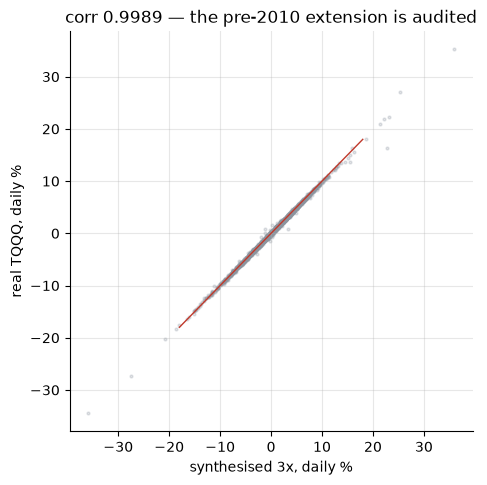

In [2]:
if HAVE_REAL:
    v = data.validate_sim3x(PX)
    print("common span %s -> %s (%d days)" % (v["start"], v["end"], v["n_days"]))
    print("daily-return corr    : %.4f" % v["corr"])
    print("residual drag        : %+.2f%%/yr after the %.1f%%/yr all-in fee"
          % (v["resid_drag_ann_pct"], data.SIM3X_FEE * 100))
    print("RMS tracking error   : %.1f bps/day" % v["rms_te_bps"])
    print("terminal-NAV ratio   : %.3f (real / sim)" % v["nav_ratio"])
    common = TQQQ.index.intersection(SIM3.index)
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    ax.scatter(SIM3.loc[common] * 100, TQQQ.loc[common] * 100, s=4, alpha=.25, color=GREY)
    lim = 18
    ax.plot([-lim, lim], [-lim, lim], color=RED, lw=1)
    ax.set_xlabel("synthesised 3x, daily %"); ax.set_ylabel("real TQQQ, daily %")
    ax.set_title("corr %.4f — the pre-2010 extension is audited" % v["corr"])
    plt.show()


## 2 — Headline race (net of 5 bps, 1999-12-22 → 2026-06-30)

> 💡 **In plain words:** over the full history the rotation earns ~2.5 pp/yr more than QQQ — with double the volatility and a deeper worst loss. The 3x-forever leg is the melting-ice grave.

In [3]:
if HAVE_REAL:
    idx = ROT.index
    rows = [("rotation", ROT), ("QQQ B&H", QQQ.reindex(idx)), ("3x B&H (sim)", SIM3.reindex(idx))]
    print("%-14s %8s %7s %8s %9s %8s" % ("leg", "CAGR%", "vol%", "Sharpe", "MaxDD%", "$1 -> "))
    for nm, r in rows:
        s = st.perf_stats(r, RF)
        print("%-14s %+8.2f %7.1f %+8.3f %+9.2f %8.2f" %
              (nm, s["cagr_pct"], s["vol_pct"], s["sharpe"], s["maxdd_pct"], s["final_mult"]))
    pos = st.positions(SIG, SIM3.index)
    print("exposure %.1f%% of days | %d switches (%.1f/yr)"
          % (pos.mean() * 100, NSW, NSW / (len(idx) / 252)))


leg               CAGR%    vol%   Sharpe    MaxDD%   $1 -> 
rotation         +11.50    50.9   +0.433    -95.14    17.81
QQQ B&H           +9.00    26.8   +0.384    -82.96     9.77
3x B&H (sim)      -2.11    80.4   +0.353    -99.98     0.57
exposure 73.7% of days | 186 switches (7.0/yr)


## 3 — Is the timing statistically real? (HAC + matched random timers)

Two tests, both on the real tape:
1. **HAC (Newey-West) t** on the daily return difference rotation − benchmark.
2. **Exposure-and-switch-matched random timers** — permute the rotation's own in/out run lengths (exposure fraction and switch count preserved exactly), rebuild the strategy per seed, average the Welch *t* over 40 seeds (single-seed baselines are banned desk-wide).

> 💡 **In plain words:** if the rule has skill, it must beat (a) plain QQQ and (b) a monkey flipping the same number of switches with the same market time. It does neither at any certifiable level.

In [4]:
if HAVE_REAL:
    h1 = st.hac_t(ROT - QQQ.reindex(ROT.index))
    h2 = st.hac_t(ROT - SIM3.reindex(ROT.index))
    print("rotation - QQQ B&H : %+.2f bps/day  HAC t = %+.2f (lags %d, n %d)"
          % (h1["mean_bps"], h1["t"], h1["lags"], h1["n"]))
    print("rotation - 3x  B&H : %+.2f bps/day  HAC t = %+.2f" % (h2["mean_bps"], h2["t"]))
    pos = st.positions(SIG, SIM3.index)
    rt = st.random_timer_test(SIM3, CASH, pos, cost_bps=5.0, n_seeds=40)
    print("\nrandom-timer baseline (40 seeds, exposure+switches matched):")
    print("  seed-averaged Welch t = %+.2f (sd %.2f)" % (rt["avg_welch_t"], rt["std_welch_t"]))
    print("  real Sharpe %+.3f vs random mean %+.3f | beats %.0f%% of seeds"
          % (rt["real_sharpe"], rt["rand_sharpe_mean"], rt["beat_frac"] * 100))


rotation - QQQ B&H : +4.67 bps/day  HAC t = +1.66 (lags 10, n 6669)
rotation - 3x  B&H : -2.50 bps/day  HAC t = -0.61

random-timer baseline (40 seeds, exposure+switches matched):
  seed-averaged Welch t = +0.05 (sd 0.37)
  real Sharpe +0.433 vs random mean +0.314 | beats 78% of seeds


## 4 — Decomposition: WHY it half-works (mean channel vs vol channel)

Condition next-day QQQ on the (lagged) SMA state.

> 💡 **In plain words:** below the line the market is twice as stormy — that's real and enormous. But the average next-day move is the same on both sides. The SMA forecasts *variance*, not *drift*; a variance forecast helps a 1x portfolio's Sharpe but cannot certify a CAGR edge for a 3x rocket.

In [5]:
if HAVE_REAL:
    c = st.sma_conditioning(QQQ, SIG)
    print("mean channel: above %+.2f bps (n=%d) vs below %+.2f bps (n=%d)  Welch t = %+.2f"
          % (c["mean_above_bps"], c["n_above"], c["mean_below_bps"], c["n_below"], c["welch_t_mean"]))
    print("vol  channel: above %.1f%% vs below %.1f%% ann. (%.2fx)  Welch t (sq. ret) = %+.2f"
          % (c["vol_above_pct"], c["vol_below_pct"],
             c["vol_below_pct"] / c["vol_above_pct"], c["welch_t_var"]))


mean channel: above +5.08 bps (n=4915) vs below +4.18 bps (n=1754)  Welch t = +0.14
vol  channel: above 19.8% vs below 40.4% ann. (2.05x)  Welch t (sq. ret) = +13.79


## 5 — Costs and the SMA-window sweep

> 💡 **In plain words:** trading costs are a rounding error at 7 switches/yr — the strategy's problem was never the broker. And the *t* crosses 2 only at the post-hoc best window (250 days), the classic shape of parameter fishing.

In [6]:
if HAVE_REAL:
    print("cost sweep (one-way bps x NAV per switch):")
    for cb in (0.0, 2.0, 5.0, 10.0):
        r, _ = st.rotation_returns(SIM3, CASH, SIG, cost_bps=cb)
        s = st.perf_stats(r, RF)
        print("  %4.1f bps: CAGR %+6.2f%%  Sharpe %+.3f  MaxDD %+.1f%%"
              % (cb, s["cagr_pct"], s["sharpe"], s["maxdd_pct"]))
    print("\nSMA-window sweep (net of 5 bps):")
    for w in (150, 200, 250):
        sg = st.sma_signal(PX["QQQ"].dropna(), window=w)
        r, ns = st.rotation_returns(SIM3, CASH, sg, cost_bps=5.0)
        r = r.reindex(ROT.index).dropna()
        s = st.perf_stats(r, RF)
        h = st.hac_t(r - QQQ.reindex(r.index))
        print("  SMA %d: CAGR %+6.2f%%  MaxDD %+.1f%%  switches %d  HAC t vs QQQ = %+.2f"
              % (w, s["cagr_pct"], s["maxdd_pct"], ns, h["t"]))


cost sweep (one-way bps x NAV per switch):
   0.0 bps: CAGR +11.89%  Sharpe +0.440  MaxDD -95.1%
   2.0 bps: CAGR +11.73%  Sharpe +0.437  MaxDD -95.1%
   5.0 bps: CAGR +11.50%  Sharpe +0.433  MaxDD -95.1%
  10.0 bps: CAGR +11.10%  Sharpe +0.426  MaxDD -95.2%

SMA-window sweep (net of 5 bps):
  SMA 150: CAGR +10.24%  MaxDD -98.6%  switches 220  HAC t vs QQQ = +1.37
  SMA 200: CAGR +11.50%  MaxDD -95.1%  switches 186  HAC t vs QQQ = +1.66
  SMA 250: CAGR +14.38%  MaxDD -86.9%  switches 146  HAC t vs QQQ = +2.11


## 6 — Sub-periods: two failure modes on the tape

> 💡 **In plain words:** slow bears (2022) are the rule's home turf. Parabolic tops (2000) leave the exit line miles below the price, and V-crashes (2020) whipsaw it — sell low, re-buy high.

In [7]:
if HAVE_REAL:
    pos = st.positions(SIG, SIM3.index)
    subs = st.SUBPERIODS + [("2020 full year", "2020-01-01", "2020-12-31")]
    print("%-24s %18s %18s %18s %s" % ("window", "rotation", "QQQ", "3x B&H", "switches"))
    for nm, a, b in subs:
        w1, w2, w3 = (st.window_stats(x, a, b) for x in (ROT, QQQ, SIM3))
        psub = pos.loc[a:b]
        nsw_sub = int((psub.values[1:] != psub.values[:-1]).sum())
        print("%-24s %+7.1f%% (dd %+5.1f%%) %+6.1f%% (dd %+5.1f%%) %+6.1f%% (dd %+5.1f%%)   %d"
              % (nm, w1["total_pct"], w1["maxdd_pct"], w2["total_pct"], w2["maxdd_pct"],
                 w3["total_pct"], w3["maxdd_pct"], nsw_sub))


window                             rotation                QQQ             3x B&H switches
dot-com crash 2000-02      -91.8% (dd -92.3%)  -82.7% (dd -83.0%) -100.0% (dd -100.0%)   21
GFC 2007-09                -54.6% (dd -56.6%)  -52.3% (dd -53.4%)  -94.4% (dd -94.6%)   15
COVID crash 2020           -41.5% (dd -55.3%)   -6.5% (dd -28.6%)  -38.5% (dd -69.7%)   4
2022 bear                  -42.9% (dd -45.6%)  -32.6% (dd -34.8%)  -79.0% (dd -80.9%)   9
2020 full year            +100.9% (dd -55.3%)  +48.4% (dd -28.6%) +111.4% (dd -69.7%)   4


## 7 — The third axis: the 2000 cohort's ledger

$10,000 at the 2000-03-24 QQQ peak — the entry the 2010+ backtests cannot contain.

> 💡 **In plain words:** the "protected" plan still fell to $507 and took 18 years to get back to even. It beats the alternative that dies ($2, never recovers) — but a −95% loss is precisely the 3x crash the plan promised away. **Busted.**

rotation   trough $     507  maxDD  -95.14%  whole again 2018-06-14  final $    104982
QQQ B&H    trough $    1729  maxDD  -82.96%  whole again 2015-02-13  final $     75338
3x B&H     trough $       2  maxDD  -99.98%  whole again NEVER       final $      3349


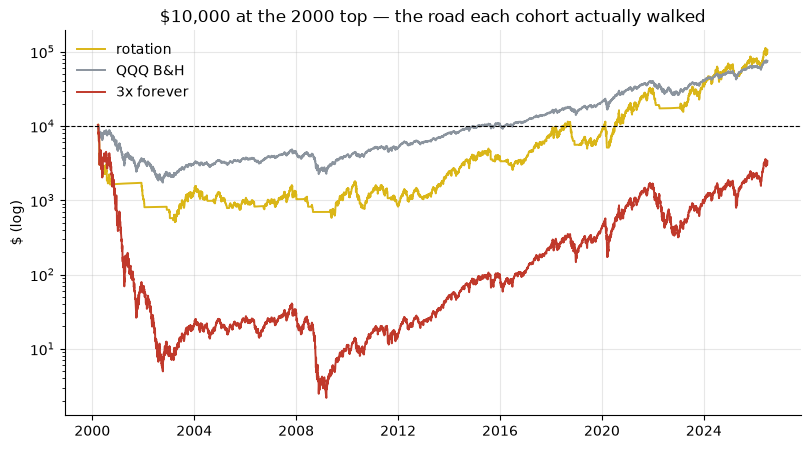

In [8]:
if HAVE_REAL:
    co = st.cohort_2000(ROT, QQQ.reindex(ROT.index), SIM3.reindex(ROT.index))
    for nm, label in [("rotation", "rotation"), ("qqq_bh", "QQQ B&H"), ("tqqq_bh", "3x B&H")]:
        d = co[nm]
        rec = d["recovered_on"] or "NEVER"
        print("%-10s trough $%8.0f  maxDD %+7.2f%%  whole again %-11s final $%10.0f"
              % (label, d["trough_value"], d["maxdd_pct"], rec, d["final_value"]))
    fig, ax = plt.subplots()
    start = "2000-03-24"
    for r, c, lb in [(ROT.loc[start:], AMBER, "rotation"),
                     (QQQ.reindex(ROT.index).loc[start:], GREY, "QQQ B&H"),
                     (SIM3.reindex(ROT.index).loc[start:], RED, "3x forever")]:
        navs = 10_000 * np.exp(np.log1p(r.dropna()).cumsum())
        ax.plot(navs, color=c, lw=1.4, label=lb)
    ax.axhline(10_000, color="k", lw=.8, ls="--")
    ax.set_yscale("log"); ax.set_ylabel("$ (log)")
    ax.set_title("$10,000 at the 2000 top — the road each cohort actually walked")
    ax.legend(frameon=False)
    plt.show()


## 8 — The window the Reddit posts show (real TQQQ, 2010+)

> 💡 **In plain words:** start the chart in 2010 and the rotation finally beats QQQ with a *t* above 2 — but that window begins right after the one regime that kills the rule (start-date selection, not certification). And on that same window it significantly **lagged** just holding TQQQ: the filter only cost money once the crash it guards against stopped happening.

In [9]:
if HAVE_REAL:
    rot_tq, nsw_tq = st.rotation_returns(TQQQ, CASH, SIG, cost_bps=5.0)
    print("corr(rotation on real TQQQ, rotation on sim 3x) = %.4f"
          % rot_tq.corr(ROT.reindex(rot_tq.index)))
    for nm, r in [("rotation (real TQQQ)", rot_tq),
                  ("QQQ B&H", QQQ.reindex(rot_tq.index)), ("TQQQ B&H", TQQQ)]:
        s = st.perf_stats(r, RF)
        print("%-22s CAGR %+7.2f%%  Sharpe %+.3f  MaxDD %+6.1f%%"
              % (nm, s["cagr_pct"], s["sharpe"], s["maxdd_pct"]))
    print("rotation - QQQ  (2010+): HAC t = %+.2f  <- bull-heavy sub-sample"
          % st.hac_t(rot_tq - QQQ.reindex(rot_tq.index))["t"])
    print("rotation - TQQQ (2010+): HAC t = %+.2f  <- lagged holding TQQQ outright"
          % st.hac_t(rot_tq - TQQQ.reindex(rot_tq.index))["t"])


corr(rotation on real TQQQ, rotation on sim 3x) = 0.9992
rotation (real TQQQ)   CAGR  +33.30%  Sharpe +0.820  MaxDD  -55.9%
QQQ B&H                CAGR  +19.91%  Sharpe +0.913  MaxDD  -35.1%
TQQQ B&H               CAGR  +44.12%  Sharpe +0.883  MaxDD  -81.7%
rotation - QQQ  (2010+): HAC t = +2.52  <- bull-heavy sub-sample
rotation - TQQQ (2010+): HAC t = -2.02  <- lagged holding TQQQ outright


## 9 — Synthetic control (machinery proof — never market evidence)

A pipeline that can't bank a planted signal proves nothing by finding nothing. In an i.i.d. world (no trend structure) the rotation must NOT beat the matched random timer; with planted persistent bear regimes (−0.8%/day, 2x vol) it must light up.

> 💡 **In plain words:** we test the detector on a world where the answer is known — both ways. It stays quiet when there is nothing and fires when there is something, so its silence on the real QQQ tape means something.

In [10]:
for eff, tag in [(0.0, "null (iid)     "), (0.008, "planted regimes")]:
    close = data.synthetic_world(effect=eff, n_days=7560)
    r = close.pct_change().dropna()
    zero = pd.Series(0.0, index=r.index)
    sg = st.sma_signal(close)
    p = st.positions(sg, r.index)
    res = st.random_timer_test(r, zero, p, cost_bps=5.0, n_seeds=40)
    cnd = st.sma_conditioning(r, sg)
    print("%s: avg Welch t = %+.2f (40 seeds) | real Sharpe %+.3f vs random %+.3f | "
          "mean-channel t = %+.2f"
          % (tag, res["avg_welch_t"], res["real_sharpe"], res["rand_sharpe_mean"],
             cnd["welch_t_mean"]))
print("\n(the Welch t on squared returns is anti-conservative under heavy tails, which is")
print(" why the desk's real-tape vol-channel claim leans on t = +13.79 AND a 2.05x vol ratio)")


null (iid)     : avg Welch t = -0.18 (40 seeds) | real Sharpe +0.872 vs random +0.910 | mean-channel t = -0.67


planted regimes: avg Welch t = +3.65 (40 seeds) | real Sharpe -0.208 vs random -1.019 | mean-channel t = +6.24

(the Welch t on squared returns is anti-conservative under heavy tails, which is
 why the desk's real-tape vol-channel claim leans on t = +13.79 AND a 2.05x vol ratio)


## Verdict

- **Signal — MIXED.** Real on the volatility channel (below-SMA vol 2.05× above, Welch *t* = **+13.79**), none on the return channel (HAC *t* = **+1.66** vs QQQ; seed-averaged Welch *t* = **+0.05** vs matched random timers; mean channel *t* = +0.14).
- **Tradability — MIRAGE.** Costs irrelevant (0→10 bps: 11.89%→11.10% CAGR); the path is the killer — **−95.14%** MaxDD, 18.2 years underwater, COVID whipsaw (−41.5% vs QQQ's −6.5%), and 2010+ the filter *lagged* raw TQQQ at *t* = **−2.02**. Regime-conditional leveraged beta.
- **"2000 cohort survives?" — BUSTED.** Trough **$507 / $10,000**, whole again in 2018. Only the comparison with the $2 grave survives.

*Numbers: [docs/results.md](../docs/results.md) (as-of 2026-06-30, fingerprint `82b00d3939c8`), reproduced by `python examples/verify.py`. Siblings: [110-faber-timing](../../110-faber-timing/), [100-melting-ice](../../100-melting-ice/). Research & education, not investment advice.*